Taille du dataset Train : (76518, 38)
Taille du dataset Test  : (51012, 37)

Valeurs manquantes par colonne :
 Series([], dtype: int64)


C:\Users\Hp\AppData\Local\Temp\ipykernel_14980\1429860551.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Target', palette='viridis')


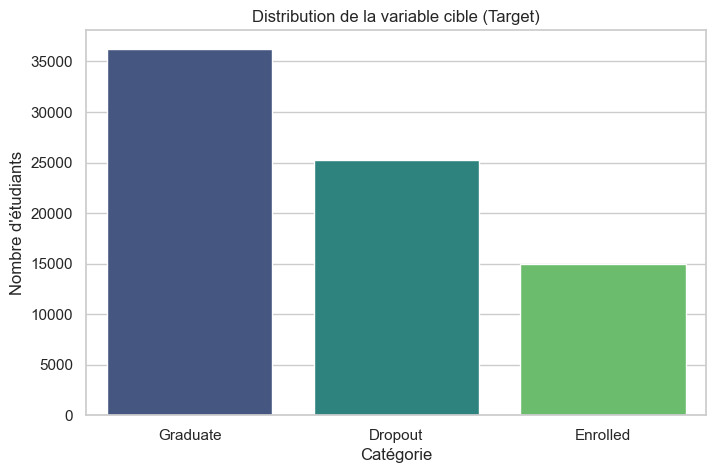


Répartition des classes en % :
Target
Graduate    47.416294
Dropout     33.058888
Enrolled    19.524818
Name: proportion, dtype: float64


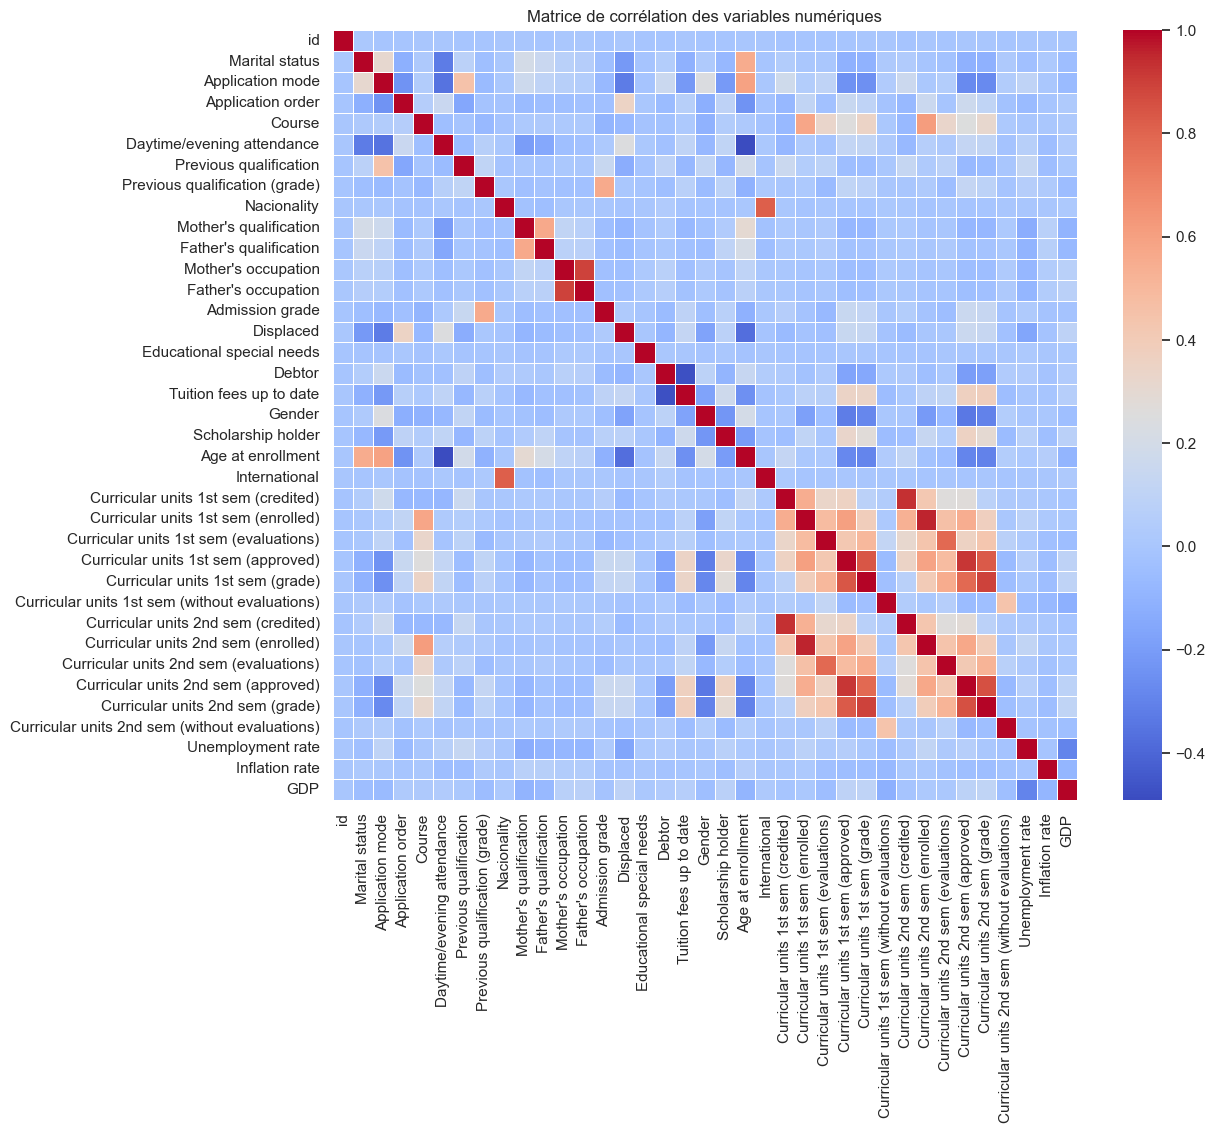


Aperçu des 5 premières lignes du dataset :


,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,1,1,1,9238,1,1,126.0,1,1,...,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,1,17,1,9238,1,1,125.0,1,19,...,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,2,1,17,2,9254,1,1,137.0,1,3,...,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,3,1,1,3,9500,1,1,131.0,1,19,...,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,4,1,1,2,9500,1,1,132.0,1,19,...,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Taille du dataset Train : {train_df.shape}")
print(f"Taille du dataset Test  : {test_df.shape}")

missing_values = train_df.isnull().sum()
print("\nValeurs manquantes par colonne :\n", missing_values[missing_values > 0])

if missing_values.any():
    for col in train_df.columns:
        if train_df[col].dtype in ['float64', 'int64']:
            train_df[col] = train_df[col].fillna(train_df[col].median())
    print("Les valeurs manquantes ont été imputées par la médiane.")

# 3. Visualisation de la variable cible 'Target'
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='Target', palette='viridis')
plt.title("Distribution de la variable cible (Target)")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'étudiants")
plt.show()

# Vérification de l'équilibre des classes
print("\nRépartition des classes en % :")
print(train_df['Target'].value_counts(normalize=True) * 100)

# 4. Corrélation entre les variables numériques
plt.figure(figsize=(12, 10))
numeric_cols = train_df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

# Affichage de la Heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

# Affichage des premières lignes pour inspection visuelle
print("\nAperçu des 5 premières lignes du dataset :")
display(train_df.head())

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2. FEATURE ENGINEERING CIBLÉ (Pour aider XGBoost à mieux décider)
def enhance_features_xgb(df):
    # Performance académique : Ratios de réussite
    df['S1_Ratio'] = df['Curricular units 1st sem (approved)'] / df['Curricular units 1st sem (enrolled)'].replace(0, 1)
    df['S2_Ratio'] = df['Curricular units 2nd sem (approved)'] / df['Curricular units 2nd sem (enrolled)'].replace(0, 1)
    
    # Indicateurs de trajectoire (Est-ce que l'étudiant s'améliore ou lâche prise ?)
    df['Grade_Trend'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']
    df['Approval_Trend'] = df['Curricular units 2nd sem (approved)'] - df['Curricular units 1st sem (approved)']
    
    # Pression financière (Variable binaire combinée)
    df['Financial_Secure'] = ((df['Scholarship holder'] == 1) & (df['Tuition fees up to date'] == 1)).astype(int)
    
    # Charge de travail totale
    df['Total_Workload'] = df['Curricular units 1st sem (enrolled)'] + df['Curricular units 2nd sem (enrolled)']
    
    return df

train_df = enhance_features_xgb(train_df)
test_df = enhance_features_xgb(test_df)

X = train_df.drop(['id', 'Target'], axis=1)
y = train_df['Target']
X_test_final = test_df.drop(['id'], axis=1)

# Encodage de la cible
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)

# Prétraitement : Standardisation des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)], 
    remainder='passthrough'
)

# Split avec stratification pour maintenir l'équilibre des classes
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Application du préprocesseur
X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_final)

# 4. MODÈLE XGBOOST 
xgb_single = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,    # Plus lent pour une meilleure précision
    max_depth=7,           # Un peu plus profond pour capturer les interactions
    subsample=0.8,         # Utilise 80% des données par arbre pour la robustesse
    colsample_bytree=0.8,  # Utilise 80% des features par arbre
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    tree_method='hist'     # Accélère l'entraînement
)

# Entraînement avec arrêt précoce pour éviter le sur-apprentissage
xgb_single.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100            
)

# 5. ÉVALUATION
y_pred = xgb_single.predict(X_val)
print(f"\nAccuracy Finale XGBoost : {accuracy_score(y_val, y_pred):.5f}")
print("\nClassification Report :")
print(classification_report(y_val, y_pred, target_names=label_enc.classes_))

# 6. GÉNÉRATION DU FICHIER DE SOUMISSION
final_labels = label_enc.inverse_transform(xgb_single.predict(X_test))
submission = pd.DataFrame({'id': test_df['id'], 'Target': final_labels})
submission.to_csv('submission_xgb_only.csv', index=False)
print("\nFichier 'submission_xgb_only.csv' généré avec succès !")

[0]	validation_0-mlogloss:1.04949
[100]	validation_0-mlogloss:0.50612
[200]	validation_0-mlogloss:0.45227
[300]	validation_0-mlogloss:0.44101
[400]	validation_0-mlogloss:0.43648
[500]	validation_0-mlogloss:0.43408
[600]	validation_0-mlogloss:0.43288
[700]	validation_0-mlogloss:0.43230
[800]	validation_0-mlogloss:0.43190
[900]	validation_0-mlogloss:0.43177
[999]	validation_0-mlogloss:0.43209

Accuracy Finale XGBoost : 0.83279

Classification Report :
              precision    recall  f1-score   support

     Dropout       0.90      0.83      0.86      5059
    Enrolled       0.66      0.61      0.63      2988
    Graduate       0.86      0.93      0.89      7257

    accuracy                           0.83     15304
   macro avg       0.80      0.79      0.79     15304
weighted avg       0.83      0.83      0.83     15304


Fichier 'submission_xgb_only.csv' généré avec succès !
